In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# DATASET CREATION.....
rows=300

data={
    "Age":np.random.randint(21,60,rows),
    "Experience":np.random.randint(0,20,rows),
    "Education":np.random.choice(["Bachelors", "Masters", "PhD"],rows),
    "City":np.random.choice(["Delhi","Mumbai","Chandigarh","Banglore"],rows),
    "Gender":np.random.choice(["Male","Female"],rows),
    "Joining_Date":pd.to_datetime(np.random.choice(pd.date_range(start="2010-01-01",end="2026-03 -03"),rows)),
}

dataset=pd.DataFrame(data)

# Salary logic (relistic relation)
dataset['Salary']=(
    dataset['Age']*1500+
    dataset['Experience']*3000+
    np.where(dataset['Education']=="Masters",1000,0)+
    np.where(dataset['Education']=="PhD",1000,0)+
    np.random.randint(-10000,10000,rows)
)


#Adding missing values....
for col in ['Age','Experience']:
    dataset.loc[np.random.choice(dataset.index,10),col]=np.nan
    
#Add duplicates.......
dataset=pd.concat([dataset,dataset.iloc[:10]],ignore_index=True)

#saving dataset as csv
dataset.to_csv("employee_salary.csv",index=False)

In [27]:
dataset.isnull().sum()

Age             10
Experience      10
Education        0
City             0
Gender           0
Joining_Date     0
Salary           0
dtype: int64

In [28]:
dataset.shape

(310, 7)

In [29]:
# handling duplicates and missing data
dataset.drop_duplicates(inplace=True)

In [30]:
# dataset.bfill(inplace=True
dataset.fillna(dataset.mean(numeric_only=True), inplace=True)

,Age,Experience,Education,City,Gender,Joining_Date,Salary
0,55.0,6.0,Bachelors,Delhi,Male,2014-06-06,94381
1,44.0,13.0,Bachelors,Banglore,Male,2014-09-17,106896
2,41.0,1.0,Masters,Mumbai,Male,2016-07-17,68182
3,39.0,2.0,Bachelors,Banglore,Male,2013-06-17,58516
4,46.0,5.0,Masters,Banglore,Female,2023-01-11,80531
...,...,...,...,...,...,...,...
295,32.0,0.0,Masters,Delhi,Male,2017-04-17,41546
296,44.0,12.0,Bachelors,Mumbai,Male,2020-06-24,98940
297,27.0,2.0,Bachelors,Delhi,Female,2019-10-11,37545
298,37.0,9.0,Bachelors,Chandigarh,Female,2018-07-25,90616


In [31]:
dataset.isnull().sum()

Age             0
Experience      0
Education       0
City            0
Gender          0
Joining_Date    0
Salary          0
dtype: int64

In [32]:
# changing datatype of joining_date to date
dataset['Joining_Date']=pd.to_datetime(dataset['Joining_Date'])



In [33]:
# now extracting important data

dataset['Year'] = dataset['Joining_Date'].dt.year
dataset.drop('Joining_Date', axis=1, inplace=True)

In [34]:
# Encoding..........
dataset=pd.get_dummies(dataset,columns=['Education','City','Gender'],drop_first=True)

In [35]:
#  Handling Outliers....
q1=dataset['Salary'].quantile(0.25)
q3=dataset['Salary'].quantile(0.75)
IQR=q3-q1
min_range=q1-1.5*IQR
max_range=q3+1.5*IQR
dataset=dataset[(dataset['Salary']>=min_range)&(dataset['Salary']<=max_range)]

In [36]:
# Feature and Target 
x=dataset.iloc[:,:-1]
y=dataset['Salary']

In [37]:
#  Train And Test 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [38]:
# Feature Scalling..
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train = ss.fit_transform(x_train) # fit ONLY on train
x_test = ss.transform(x_test)   # transform test

In [39]:
# Model Training....
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
# Prediction
y_pred=model.predict(x_test)

In [41]:
# Accuracy
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 1.0


In [42]:
model.score(x_test,y_test)

1.0

In [43]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head(10))


     Actual  Predicted
203  128542   128542.0
266   80845    80845.0
152  107970   107970.0
9     80722    80722.0
233   75174    75174.0
226   69136    69136.0
196   87240    87240.0
109  130061   130061.0
5     95714    95714.0
175   92849    92849.0


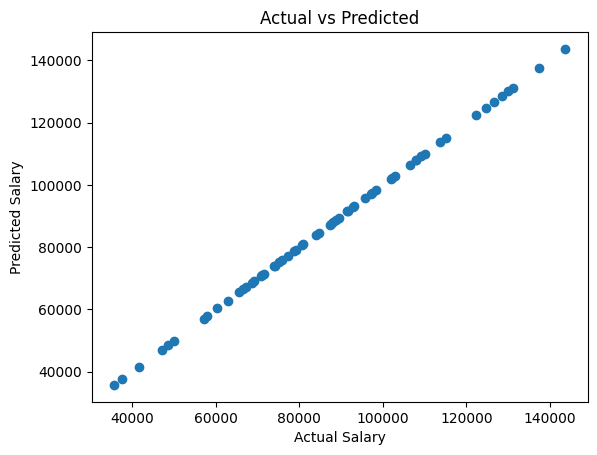

In [44]:
# visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.savefig("ScatterGraph.png") 
plt.show()

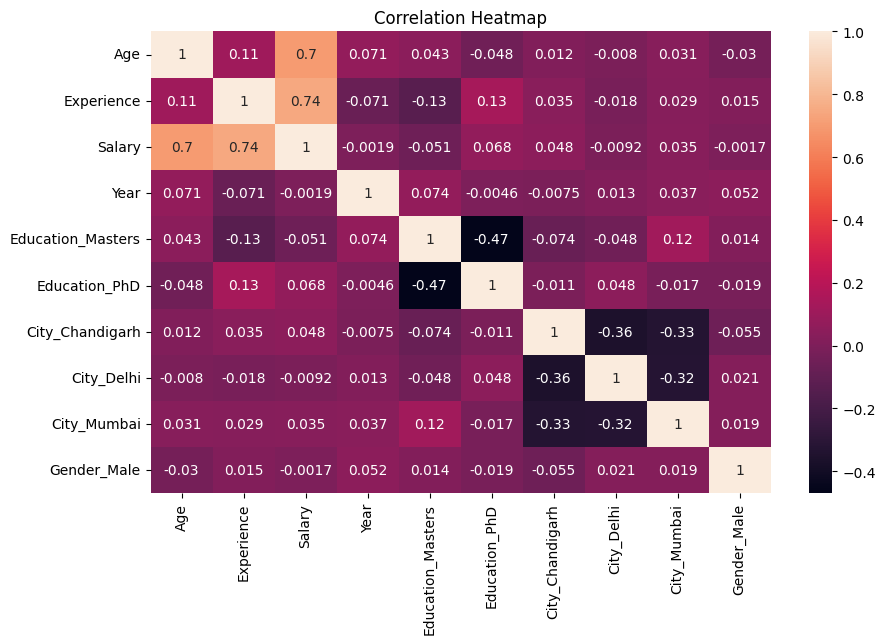

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(dataset.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("Heatmap.png") 
plt.show()

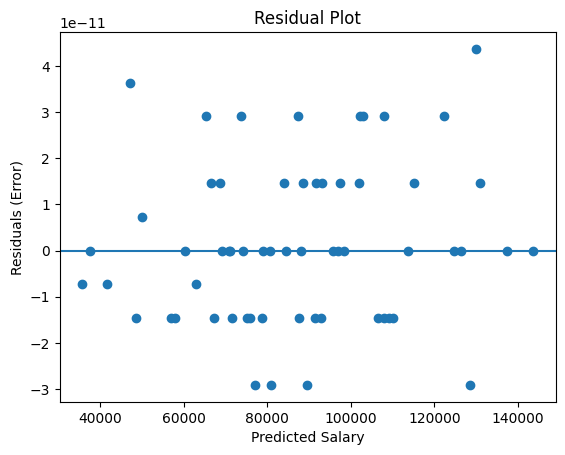

In [46]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.savefig("ScatterGraph1.png") 
plt.show()

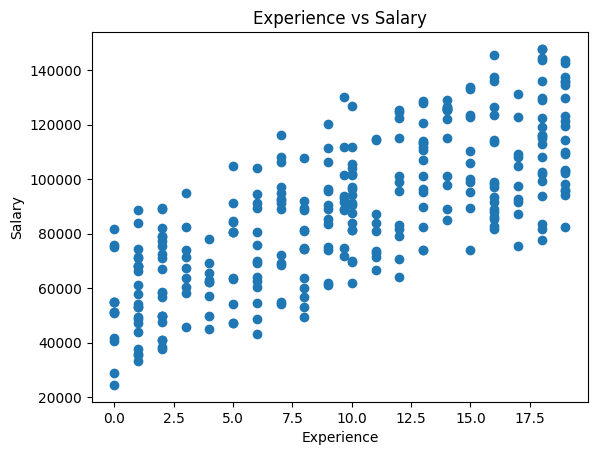

In [47]:
plt.scatter(dataset['Experience'], dataset['Salary'])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.savefig("Experience_vs_Salary.png") 
plt.show()